# Stroke Prediction: Decision Tree & KNN Models


# 1. Data Preparation

---



In [223]:
#Importing all the necessary libraries.

import pandas as pd
import numpy as np
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold

from sklearn import tree
from matplotlib import pyplot as plt
import seaborn as sns

#Load Dataset



In [224]:
# Upload the stroke prediction dataset file from local machine

from google.colab import files
uploaded = files.upload()

In [225]:
# Download the stroke prediction dataset from Kaggle using kagglehub

path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")

csv_path = f"{path}/healthcare-dataset-stroke-data.csv"

df = pd.read_csv(csv_path)

print("Column headers:", df.columns.tolist())

Column headers: ['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']


# 2. Decision Tree Model


---



# STEP 1: Understand the dataframe


In [226]:
#Displaying basic information about the dataset: number of rows and columns,
# feature names, and the data types of each column

print("Informations of Database:")
print("• Number of rows : ", df.shape[0])    #rows=dataframe.shape[0]
print("• Number of columns : ", df.shape[1])  #columns=dataframe.shape[1]
print("• Names and Types of features : \n", df.dtypes)

Informations of Database:
• Number of rows :  5110
• Number of columns :  12
• Names and Types of features : 
 id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object


In [227]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [228]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
None


In [229]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


# STEP 2: Preprocess the data

#Handle Missing Values

In [230]:
df.drop("id", axis=1, inplace=True)

# Display missing values
print("Missing values before handling:")
print(df.isnull().sum())

# Imputation (Filling In Missing Values)
df['bmi'] = df['bmi'].fillna(df['bmi'].mean())

# Check if there are still missing values
print("\nMissing values after handling:")
print(df.isnull().sum())

Missing values before handling:
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Missing values after handling:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


# Encoding categorical variables into numeric format for model training

In [231]:
print(df['gender'].value_counts())
print("\n")
print(df['ever_married'].value_counts())
print("\n")
print(df['work_type'].value_counts())
print("\n")
print(df['Residence_type'].value_counts())
print("\n")
print(df['smoking_status'].value_counts())

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64


ever_married
Yes    3353
No     1757
Name: count, dtype: int64


work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64


Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64


smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64


In [232]:
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1, 'Other': 2})

df['ever_married'] = df['ever_married'].map({'No': 0, 'Yes': 1})

df['work_type'] = df['work_type'].map({'Private': 0,
                                        'Self-employed': 1,
                                       'children': 2,
                                       'Govt_job': 3,
                                       'Never_worked': 4})

df['Residence_type'] = df['Residence_type'].map({'Urban': 0, 'Rural': 1})

df['smoking_status'] = df['smoking_status'].map({'never smoked': 0,
                                                'formerly smoked': 1,
                                                'smokes': 2,
                                                 'Unknown': -1})

# Using one-hot encoding as an alternative

In [233]:
# One-hot encoding for categorical variables
df = pd.get_dummies(df, drop_first=True)
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,67.0,0,1,1,0,0,228.69,36.600000,1,1
1,1,61.0,0,0,1,1,1,202.21,28.893237,0,1
2,0,80.0,0,1,1,0,1,105.92,32.500000,0,1
3,1,49.0,0,0,1,0,0,171.23,34.400000,2,1
4,1,79.0,1,0,1,1,1,174.12,24.000000,0,1


# Confirm the updatted types of data

In [234]:
df.dtypes

,0
gender,int64
age,float64
hypertension,int64
heart_disease,int64
ever_married,int64
work_type,int64
Residence_type,int64
avg_glucose_level,float64
bmi,float64
smoking_status,int64


In [235]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,67.0,0,1,1,0,0,228.69,36.600000,1,1
1,1,61.0,0,0,1,1,1,202.21,28.893237,0,1
2,0,80.0,0,1,1,0,1,105.92,32.500000,0,1
3,1,49.0,0,0,1,0,0,171.23,34.400000,2,1
4,1,79.0,1,0,1,1,1,174.12,24.000000,0,1


# Perform exploratory data analysis (EDA) using graphs

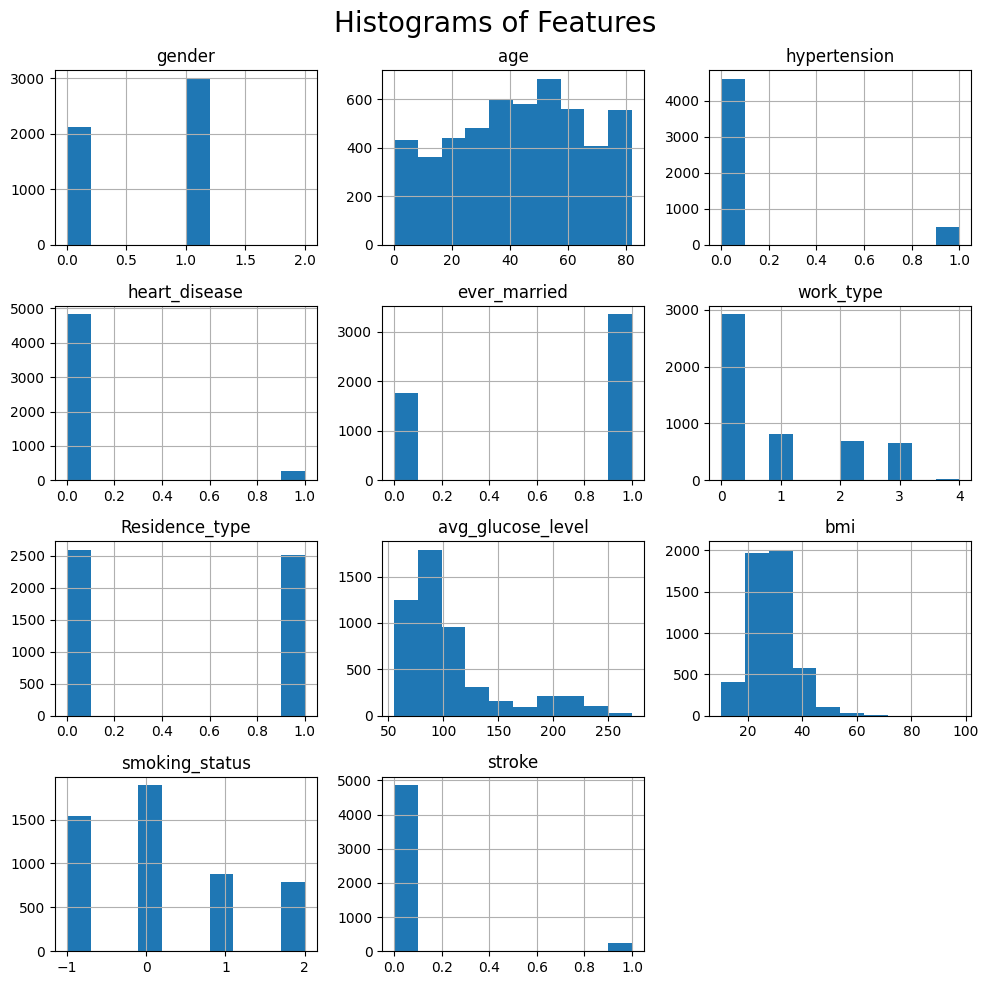

In [236]:

# Plotting histograms to visualize how the values are distributed across each numeric feature
# in the dataset before performing further analysis

df.hist(figsize=(10,10))
plt.suptitle('Histograms of Features', fontsize=20)
plt.tight_layout()
plt.show()

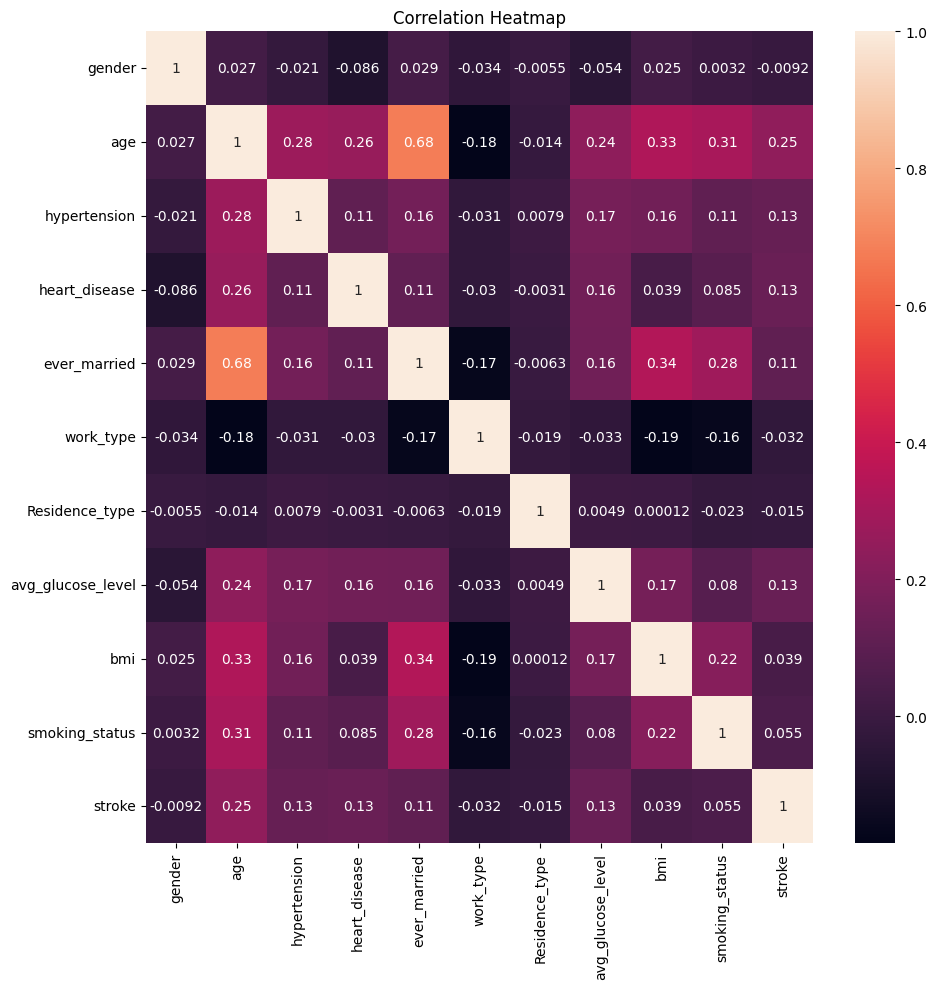

In [237]:
# Plotting a correlation heatmap to visualize the relationships
#between numeric features in the dataset

fig = plt.figure(figsize=(10,10))
plt.title("Correlation Heatmap")
_=sns.heatmap(df.corr(),  annot=True)
plt.tight_layout()
plt.show()

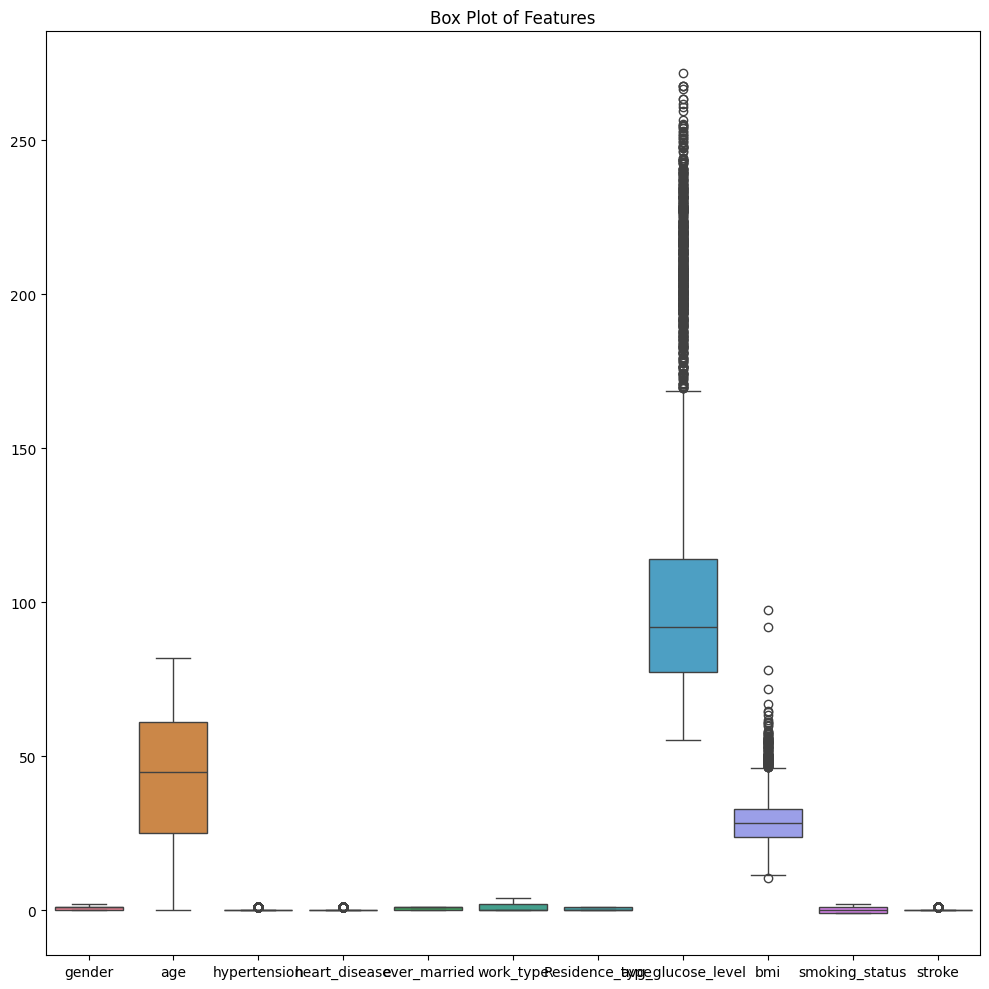

In [238]:
# Plotting boxplot to visualize the distribution, spread,
#skewness, and outliers in dataframe.

fig=plt.figure(figsize=(10,10))
_=sns.boxplot(df)
plt.title('Box Plot of Features')
plt.tight_layout()
plt.show()

# STEP 3: Train and Evaluate a Decision Tree Classifier



# Split Features and Data

In [239]:
#Train the model

# Define features (X) and stroke (y)
X = df.drop(['stroke'], axis=1)
y=df['stroke']

# Split the data into training and testing sets (72% train, 28% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.28, random_state=42)

In [240]:
#Initialize and train a Decision Tree model on the dataset

dt = DecisionTreeClassifier() #initialize
dt.fit(X_train, y_train) #train

# Predictions and evaluation
y_pred_dt = dt.predict(X_test)
print("Decision Tree Classification Report:\n")
print(classification_report(y_test, y_pred_dt))

Decision Tree Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      1345
           1       0.24      0.22      0.23        86

    accuracy                           0.91      1431
   macro avg       0.59      0.59      0.59      1431
weighted avg       0.91      0.91      0.91      1431



# Evaluate Model

In [241]:
#Predict on test data

predictions = dt.predict(X_test)
predictions

array([0, 0, 0, ..., 0, 0, 0])

In [242]:
dt.predict_proba(X_test) #probabilities for each class

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       ...,
       [1., 0.],
       [1., 0.],
       [1., 0.]])

# Using accuracy, precision, recall, f1 score for evaluating the model

In [243]:
print("Accuracy:", accuracy_score(y_test, predictions))
print("Precision:",precision_score(y_test, predictions))
print("Recall:",recall_score(y_test, predictions))
print("F1 Score:",f1_score(y_test, predictions))

Accuracy: 0.9105520614954578
Precision: 0.2375
Recall: 0.22093023255813954
F1 Score: 0.2289156626506024


In [244]:
#evaluate the classifier’s performance

report = classification_report(y_test, predictions, target_names=['No Stroke', 'Stroke'])
print(report)

              precision    recall  f1-score   support

   No Stroke       0.95      0.95      0.95      1345
      Stroke       0.24      0.22      0.23        86

    accuracy                           0.91      1431
   macro avg       0.59      0.59      0.59      1431
weighted avg       0.91      0.91      0.91      1431



# Select only the Most Important Features for Improved Model Performance

In [245]:
feature_names=X.columns
feature_importance = pd.DataFrame(dt.feature_importances_, index = feature_names).sort_values(0, ascending=False)
feature_importance

,0
avg_glucose_level,0.293349
age,0.236078
bmi,0.227250
smoking_status,0.056827
work_type,0.043956
Residence_type,0.043376
heart_disease,0.040641
hypertension,0.030113
gender,0.022152
ever_married,0.006257


In [246]:
features = list(feature_importance[feature_importance[0]>0].index)
print('The most import features are:\n', features)

The most import features are:
 ['avg_glucose_level', 'age', 'bmi', 'smoking_status', 'work_type', 'Residence_type', 'heart_disease', 'hypertension', 'gender', 'ever_married']


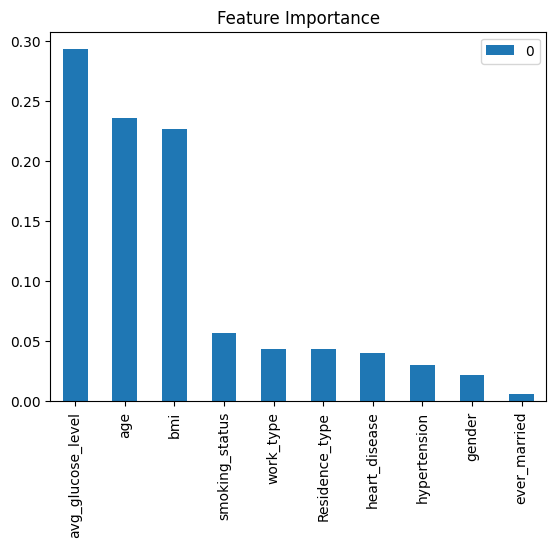

In [247]:
feature_importance.head(10).plot(kind='bar')
plt.title("Feature Importance")
plt.show()

In [248]:
low_importance = list(feature_importance[feature_importance[0]<0.03].index)

# Drop low importance features from the first dataframe X
# Removal (Drop Missing Data)
df = df.drop(columns=low_importance)
df.head()

,age,hypertension,heart_disease,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,67.0,0,1,0,0,228.69,36.600000,1,1
1,61.0,0,0,1,1,202.21,28.893237,0,1
2,80.0,0,1,0,1,105.92,32.500000,0,1
3,49.0,0,0,0,0,171.23,34.400000,2,1
4,79.0,1,0,1,1,174.12,24.000000,0,1


In [249]:
df.head()

,age,hypertension,heart_disease,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,67.0,0,1,0,0,228.69,36.600000,1,1
1,61.0,0,0,1,1,202.21,28.893237,0,1
2,80.0,0,1,0,1,105.92,32.500000,0,1
3,49.0,0,0,0,0,171.23,34.400000,2,1
4,79.0,1,0,1,1,174.12,24.000000,0,1


#Fine-tune the Decision Tree Model

In [250]:
# Define parameter grid
param_grid = {
    'max_depth': [3, 5, 10, 15, 17],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

# Best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score (CV):", grid_search.best_score_)

# Evaluate best estimator on test set
best_dt_model = grid_search.best_estimator_
y_pred_best_dt = best_dt_model.predict(X_test)
print("Fine-tuned Decision Tree Classification Report:\n")
print(classification_report(y_test, y_pred_best_dt))

Best Parameters: {'max_depth': 17, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best F1 Score (CV): 0.14397016910272478
Fine-tuned Decision Tree Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      1345
           1       0.25      0.23      0.24        86

    accuracy                           0.91      1431
   macro avg       0.60      0.59      0.60      1431
weighted avg       0.91      0.91      0.91      1431



# Interpret the Model

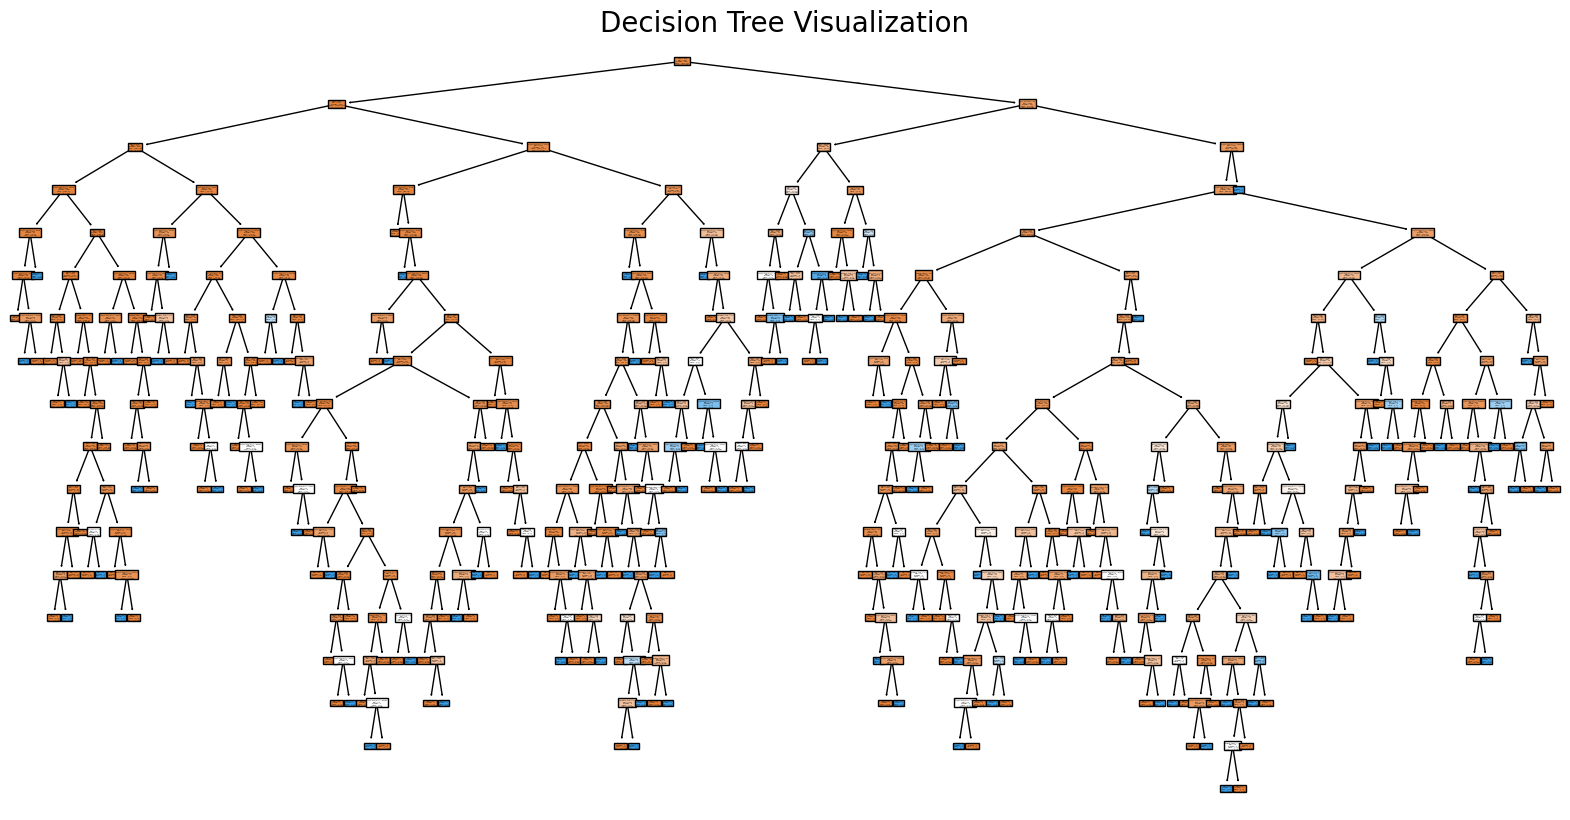

In [251]:
# Visualizing the trained decision tree
plt.figure(figsize=(20,10))
tree.plot_tree(
    best_dt_model,
    feature_names=X.columns,
    class_names=['No Stroke', 'Stroke'],
    filled=True
)
plt.title("Decision Tree Visualization", fontsize=20)
plt.show()

# 3. KNN Model

---



# Data Processing

In [252]:
df = pd.read_csv(csv_path)

print("Column headers:", df.columns.tolist())

Column headers: ['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']


In [253]:
selected_features = ['age', 'work_type', 'bmi', 'avg_glucose_level', 'smoking_status', 'stroke']
df = df[selected_features]

# Display missing values
print("Missing values before handling:")
print(df.isnull().sum())

# Imputation (Filling In Missing Values)
df['bmi'] = df['bmi'].fillna(df['bmi'].mean())

# Display missing values
print("\nMissing values after handling:")
print(df.isnull().sum())

Missing values before handling:
age                    0
work_type              0
bmi                  201
avg_glucose_level      0
smoking_status         0
stroke                 0
dtype: int64

Missing values after handling:
age                  0
work_type            0
bmi                  0
avg_glucose_level    0
smoking_status       0
stroke               0
dtype: int64


In [254]:
df['work_type'] = df['work_type'].map({'Private': 0,
                                        'Self-employed': 1,
                                       'children': 2,
                                       'Govt_job': 3,
                                       'Never_worked': 4})

df['smoking_status'] = df['smoking_status'].map({'never smoked': 0,
                                                'formerly smoked': 1,
                                                'smokes': 2,
                                                 'Unknown': -1})

In [255]:
# Define features (X) and stroke (y)
X_knn = df.drop(['stroke'], axis=1)
y=df['stroke']

# Feature Scaling

In [256]:
scaler = StandardScaler()
X_knn_scaled = scaler.fit_transform(X_knn)

# Spil the data

In [257]:
# Train-test split (80/20)
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(X_knn_scaled, y,
                                                                    test_size=0.20,
                                                                    random_state=42)

# Build the KNN Model

In [258]:
# define the parameters we are gonna iterate through

n_neighbors = list(range(1,15))

test_accuracy = {}
train_accuracy = {}

for n in n_neighbors:
    clf = KNeighborsClassifier(n_neighbors = n)
    clf.fit(X_train, y_train)
    test_acc = clf.score(X_test, y_test)
    train_acc = clf.score(X_train, y_train)
    test_accuracy[n] = test_acc
    train_accuracy[n] = train_acc

In [259]:
for k, v in test_accuracy.items():
    print("test accuracy for {} n_neighbors is {} %".format(k, round(v*100, 3)))

test accuracy for 1 n_neighbors is 91.055 %
test accuracy for 2 n_neighbors is 93.92 %
test accuracy for 3 n_neighbors is 93.501 %
test accuracy for 4 n_neighbors is 93.92 %
test accuracy for 5 n_neighbors is 93.711 %
test accuracy for 6 n_neighbors is 93.781 %
test accuracy for 7 n_neighbors is 93.641 %
test accuracy for 8 n_neighbors is 93.99 %
test accuracy for 9 n_neighbors is 93.99 %
test accuracy for 10 n_neighbors is 93.99 %
test accuracy for 11 n_neighbors is 93.99 %
test accuracy for 12 n_neighbors is 93.99 %
test accuracy for 13 n_neighbors is 93.99 %
test accuracy for 14 n_neighbors is 93.99 %


In [260]:
for k, v in train_accuracy.items():
    print("training accuracy for {} n_neighbors is {} %".format(k, round(v*100, 3)))

training accuracy for 1 n_neighbors is 100.0 %
training accuracy for 2 n_neighbors is 96.004 %
training accuracy for 3 n_neighbors is 95.923 %
training accuracy for 4 n_neighbors is 95.733 %
training accuracy for 5 n_neighbors is 95.678 %
training accuracy for 6 n_neighbors is 95.624 %
training accuracy for 7 n_neighbors is 95.597 %
training accuracy for 8 n_neighbors is 95.569 %
training accuracy for 9 n_neighbors is 95.597 %
training accuracy for 10 n_neighbors is 95.569 %
training accuracy for 11 n_neighbors is 95.569 %
training accuracy for 12 n_neighbors is 95.569 %
training accuracy for 13 n_neighbors is 95.542 %
training accuracy for 14 n_neighbors is 95.569 %


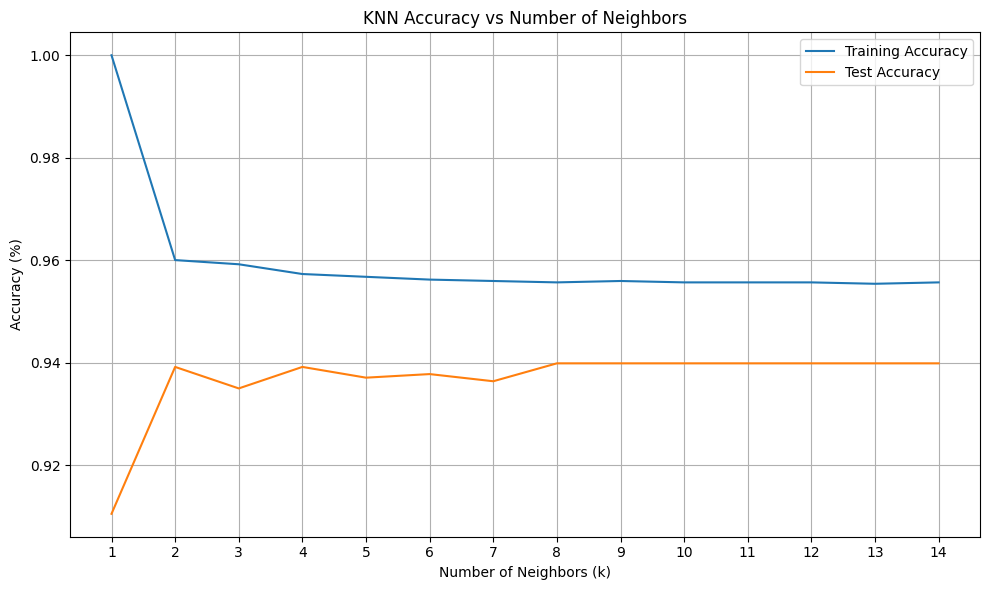

In [261]:
# Create lists for plotting
test_acc_values = [test_accuracy[n] for n in n_neighbors]
train_acc_values = [train_accuracy[n] for n in n_neighbors]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(n_neighbors, train_acc_values, label='Training Accuracy')
plt.plot(n_neighbors, test_acc_values, label='Test Accuracy')
plt.title('KNN Accuracy vs Number of Neighbors')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy (%)')
plt.xticks(n_neighbors)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Based on the diagram and the accuracy values, the best choice for n_neighbors is 8, as it delivers the highest test accuracy (93.99%) and a very good training accuracy (95.57%). That is also means that the model achieves a strong balance between learning the training data.




In [262]:
knn = KNeighborsClassifier(n_neighbors=8)
knn.fit(X_train_knn, y_train_knn)

KNeighborsClassifier(n_neighbors=8)

In [263]:
knn.get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 8,
 'p': 2,
 'weights': 'uniform'}

# Evaluate the Model


In [264]:
#evaluate the model's accuracy
training_acc=knn.score(X_train_knn, y_train_knn)
test_acc=knn.score(X_test_knn, y_test_knn)

In [265]:
training_acc, test_acc

(0.9542563600782779, 0.9393346379647749)

In [266]:
#Predict on test data

predictions_knn = knn.predict(X_test_knn)
predictions_knn

array([0, 0, 0, ..., 0, 0, 0])

In [267]:
knn.predict_proba(X_test_knn) #probabilities for each class

array([[1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       ...,
       [1.  , 0.  ],
       [1.  , 0.  ],
       [0.75, 0.25]])

In [268]:
print("Accuracy:", accuracy_score(y_test_knn, predictions_knn))
print("Precision:",precision_score(y_test_knn, predictions_knn))
print("Recall:",recall_score(y_test_knn, predictions_knn))
print("F1 Score:",f1_score(y_test_knn, predictions_knn))

Accuracy: 0.9393346379647749
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [270]:
report = classification_report(y_test_knn, predictions_knn, target_names=['No Stroke', 'Stroke'])
print(report)

              precision    recall  f1-score   support

   No Stroke       0.94      1.00      0.97       960
      Stroke       0.00      0.00      0.00        62

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.94      0.91      1022



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Although the KNN model with k=8 shows a high accuracy of 93.93%, the precision, recall, and F1 score are all 0.0. This happens because the model predicts only the majority class and completely misses the minority class. As a result, it fails to identify any true positive cases. This is a common issue when the dataset is imbalanced, because we have a huge number of zeros and a small number of 1s. This means that accuracy alone is not enough to judge the model's performance, especially when correct classification (1 for stroke) of all classes is important.

# Fine-Tune the KNN Model

In [271]:
# Define the hyperparameter distribution
param_dist_knn = {
    'n_neighbors': range(1, 10),  # Try K from 1 to 9
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Random search with 5-fold cross-validation using F1 score
random_search_knn = RandomizedSearchCV(
    estimator=KNeighborsClassifier(),
    param_distributions=param_dist_knn,
    n_iter=20,              # Try 20 random combinations
    scoring='f1',           # F1 score (focuses on positive class)
    cv=5,
    n_jobs=-1,
    random_state=42
)

# Fit the model to the training data
random_search_knn.fit(X_train_knn, y_train_knn)

# Best parameters and F1 score
print("Best Parameters (Random Search):", random_search_knn.best_params_)
print("Best F1 Score:", random_search_knn.best_score_)

# Evaluate the best model on the test set
best_knn_model = random_search_knn.best_estimator_
y_pred_best_knn = best_knn_model.predict(X_test_knn)

print("\nFine-tuned KNN Classification Report:\n")
print(classification_report(y_test_knn, y_pred_best_knn))

Best Parameters (Random Search): {'weights': 'distance', 'n_neighbors': 2, 'metric': 'manhattan'}
Best F1 Score: 0.10508298180932452

Fine-tuned KNN Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       960
           1       0.14      0.11      0.13        62

    accuracy                           0.91      1022
   macro avg       0.54      0.53      0.54      1022
weighted avg       0.89      0.91      0.90      1022



In [272]:
best_knn_model.get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'manhattan',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 2,
 'p': 2,
 'weights': 'distance'}

# Confusion matrixes to compare results for decision tree and KNN

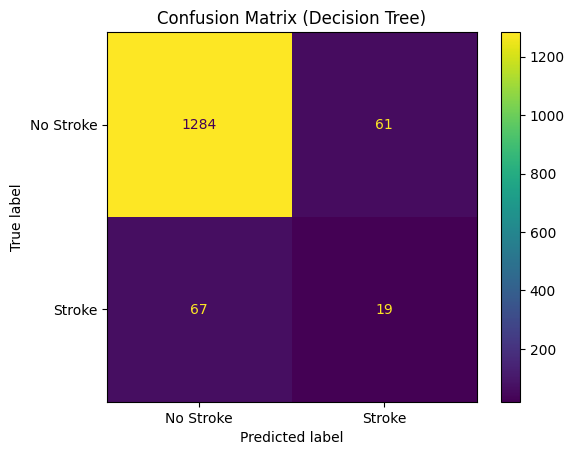

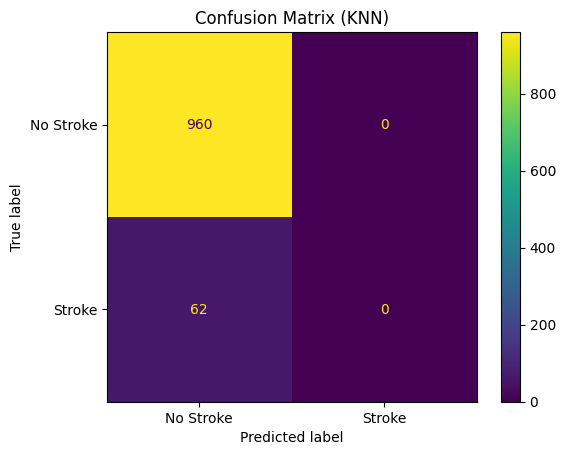

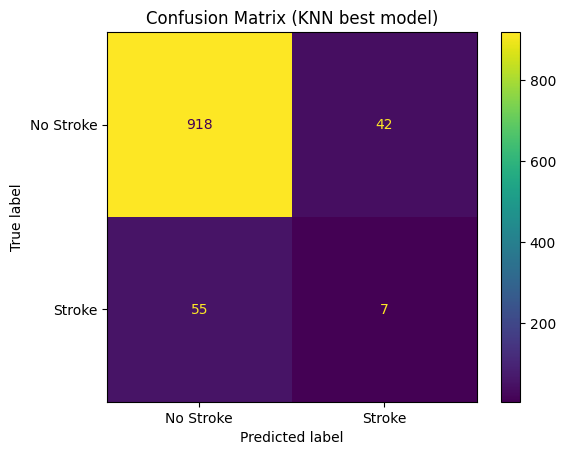

In [273]:
#Confusion Matrix

cm = confusion_matrix(y_test, predictions, labels=[0,1])
cm_knn = confusion_matrix(y_test_knn, predictions_knn, labels=[0,1])
cm_knn_best = confusion_matrix(y_test_knn, best_knn_model.predict(X_test_knn), labels=[0,1])

#Display the Confusion Matrix (Decision Tree)
dispCm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Stroke', 'Stroke'])
dispCm.plot()
plt.title("Confusion Matrix (Decision Tree)")
plt.show()

#Display the Confusion Matrix (KNN)
dispCm_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['No Stroke', 'Stroke'])
dispCm_knn.plot()
plt.title("Confusion Matrix (KNN)")
plt.show()

#Display the Confusion Matrix (KNN best model)
dispCm_knn_best = ConfusionMatrixDisplay(confusion_matrix=cm_knn_best, display_labels=['No Stroke', 'Stroke'])
dispCm_knn_best.plot()
plt.title("Confusion Matrix (KNN best model)")
plt.show()

In comparing the KNN model and the Decision Tree model using their confusion matrices, both models achieved similar overall accuracy (Decision Tree = 91% & KNN =94%) . However, when focusing on stroke prediction — which is the minority but most critical class — the Decision Tree clearly outperformed KNN.

The Decision Tree model achieved a recall of 19.8% and a precision of 23.6% for detecting stroke cases, while the KNN model had a much lower recall of only 14% and precision of 11%. This means that the Decision Tree was more effective both in identifying actual stroke cases and in making correct positive predictions.

Although both models had a high number of false negatives (missed stroke cases), KNN performed significantly worse in this regard, identifying only 7 stroke cases correctly out of 62. In contrast, the Decision Tree correctly identified 19 out of 86 stroke cases.